In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind, f_oneway, chi2_contingency
from sklearn. model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, confusion_matrix, classification_report
import warnings
import joblib
warnings.filterwarnings('ignore')

In [4]:
import pandas as pd

df = pd.read_csv(r"D:\Mlproject\Stroke Detection\healthcare-dataset-stroke-data.csv")

print(df.shape)
df.head()

(5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [5]:
df['bmi'].fillna(df['bmi'].median(), inplace=True)

print(df.isnull().sum())

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


In [6]:
df.describe(include='all')

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,5110.000000,5110,5110.000000,5110.000000,5110.000000,5110,5110,5110,5110.000000,5110.000000,5110,5110.000000
unique,NaN,3,NaN,NaN,NaN,2,5,2,NaN,NaN,4,NaN
top,NaN,Female,NaN,NaN,NaN,Yes,Private,Urban,NaN,NaN,never smoked,NaN
freq,NaN,2994,NaN,NaN,NaN,3353,2925,2596,NaN,NaN,1892,NaN
mean,36517.829354,NaN,43.226614,0.097456,0.054012,NaN,NaN,NaN,106.147677,28.862035,NaN,0.048728
std,21161.721625,NaN,22.612647,0.296607,0.226063,NaN,NaN,NaN,45.283560,7.699562,NaN,0.215320
min,67.000000,NaN,0.080000,0.000000,0.000000,NaN,NaN,NaN,55.120000,10.300000,NaN,0.000000
25%,17741.250000,NaN,25.000000,0.000000,0.000000,NaN,NaN,NaN,77.245000,23.800000,NaN,0.000000
50%,36932.000000,NaN,45.000000,0.000000,0.000000,NaN,NaN,NaN,91.885000,28.100000,NaN,0.000000
75%,54682.000000,NaN,61.000000,0.000000,0.000000,NaN,NaN,NaN,114.090000,32.800000,NaN,0.000000


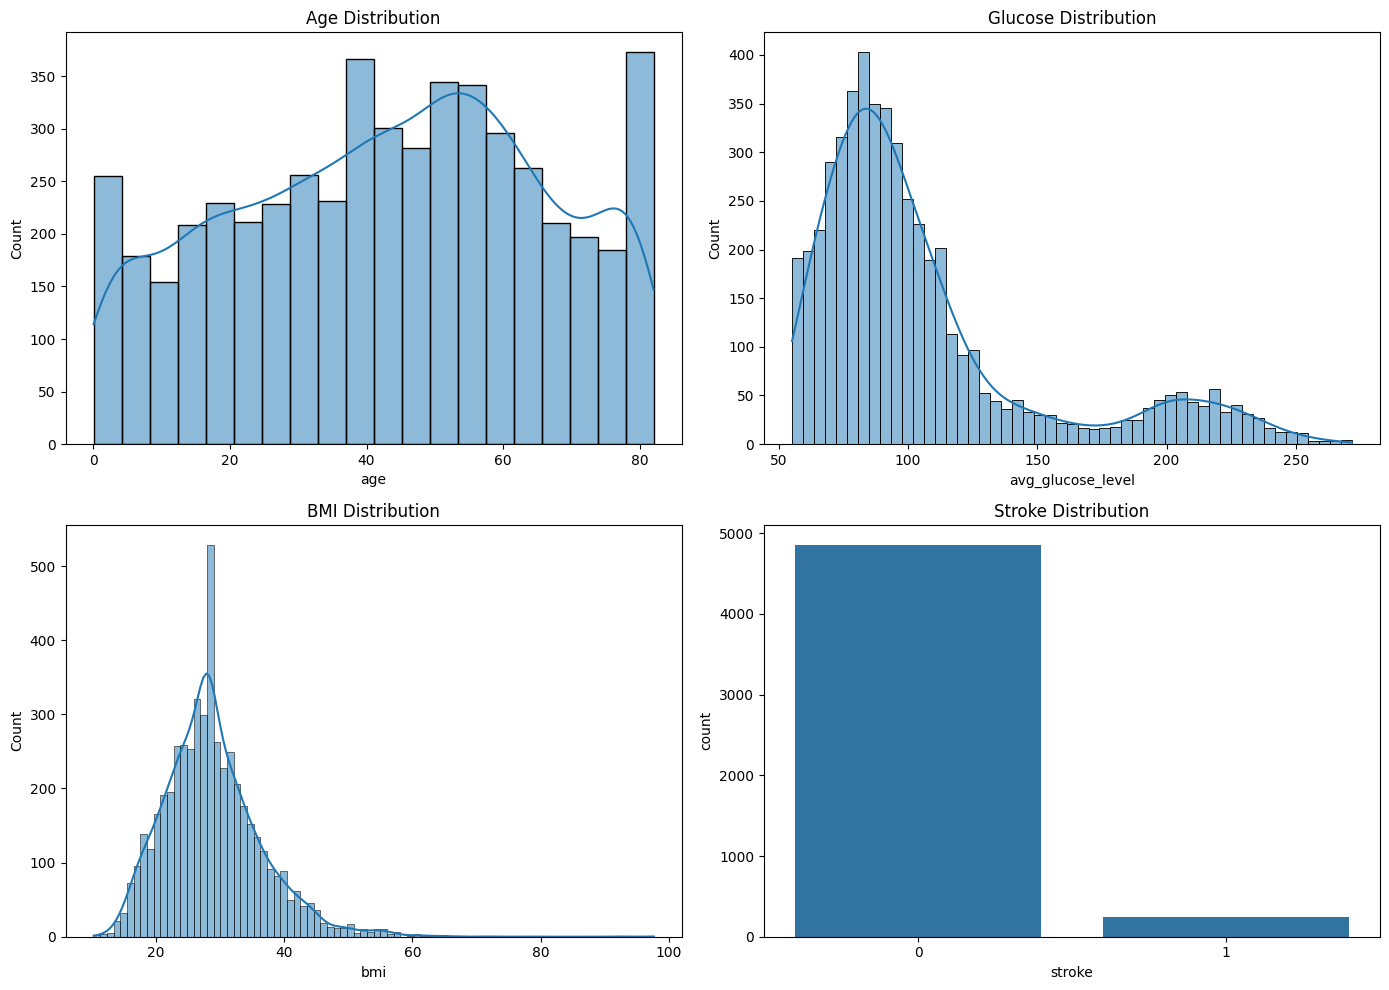

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2,2,figsize=(14,10))

sns.histplot(df['age'],kde=True,ax=axes[0,0])
axes[0,0].set_title("Age Distribution")

sns.histplot(df['avg_glucose_level'],kde=True,ax=axes[0,1])
axes[0,1].set_title("Glucose Distribution")

sns.histplot(df['bmi'],kde=True,ax=axes[1,0])
axes[1,0].set_title("BMI Distribution")

sns.countplot(x='stroke',data=df,ax=axes[1,1])
axes[1,1].set_title("Stroke Distribution")

plt.tight_layout()
plt.show()

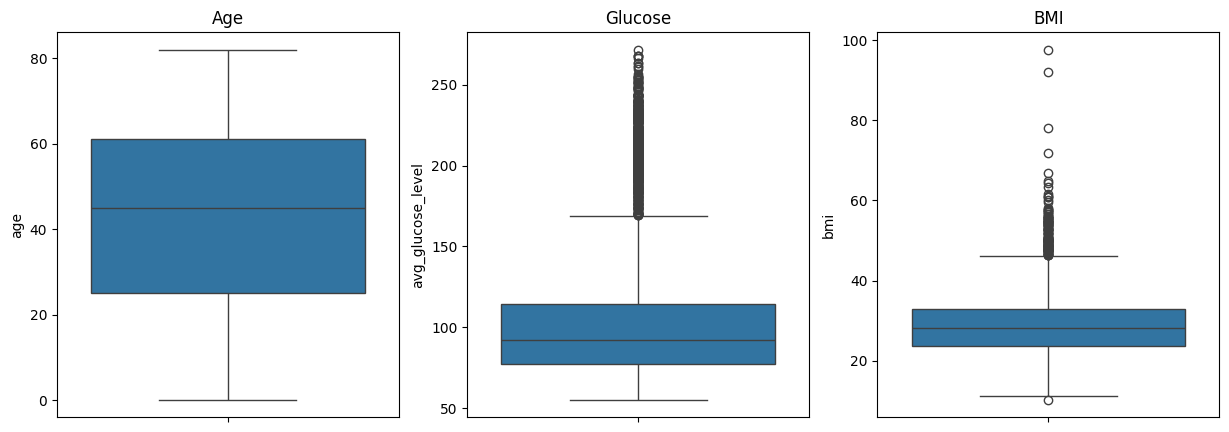

In [8]:
fig, axes = plt.subplots(1,3,figsize=(15,5))

sns.boxplot(y=df['age'],ax=axes[0])
axes[0].set_title("Age")

sns.boxplot(y=df['avg_glucose_level'],ax=axes[1])
axes[1].set_title("Glucose")

sns.boxplot(y=df['bmi'],ax=axes[2])
axes[2].set_title("BMI")

plt.show()

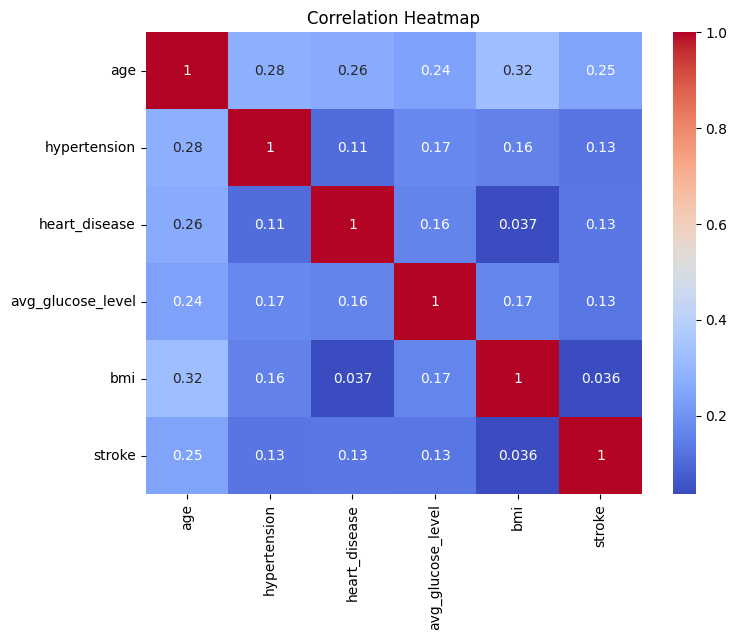

In [9]:
plt.figure(figsize=(8,6))

numeric = df[['age','hypertension','heart_disease',
              'avg_glucose_level','bmi','stroke']]

sns.heatmap(numeric.corr(),annot=True,cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

In [10]:
from scipy.stats import ttest_ind

male = df[df['gender']=="Male"]['bmi']
female = df[df['gender']=="Female"]['bmi']

t,p = ttest_ind(male,female,nan_policy='omit')

print("T Statistic :",t)
print("P Value :",p)

from scipy.stats import f_oneway

groups = [group['age'].values for name,group in df.groupby('work_type')]

f,p = f_oneway(*groups)

print("F Statistic :",f)
print("P Value :",p)

from scipy.stats import chi2_contingency

table = pd.crosstab(df['gender'],df['stroke'])

chi,p,dof,expected = chi2_contingency(table)

print("Chi Square :",chi)
print("P Value :",p)

T Statistic : -1.8910122800142644
P Value : 0.05867925148151389
F Statistic : 1110.0850632053032
P Value : 0.0
Chi Square : 0.47258662884530234
P Value : 0.7895490538408245


In [11]:
df_encoded = pd.get_dummies(df,drop_first=True)

df_encoded.head()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,gender_Other,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,9046,67.0,0,1,228.69,36.6,1,True,False,True,False,True,False,False,True,True,False,False
1,51676,61.0,0,0,202.21,28.1,1,False,False,True,False,False,True,False,False,False,True,False
2,31112,80.0,0,1,105.92,32.5,1,True,False,True,False,True,False,False,False,False,True,False
3,60182,49.0,0,0,171.23,34.4,1,False,False,True,False,True,False,False,True,False,False,True
4,1665,79.0,1,0,174.12,24.0,1,False,False,True,False,False,True,False,False,False,True,False


In [12]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(['stroke','id'],axis=1)

y = df_encoded['stroke']

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [14]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train,y_train)

prediction = model.predict(X_test)

Accuracy : 0.952054794520548
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       972
           1       1.00      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.98      0.51      0.51      1022
weighted avg       0.95      0.95      0.93      1022



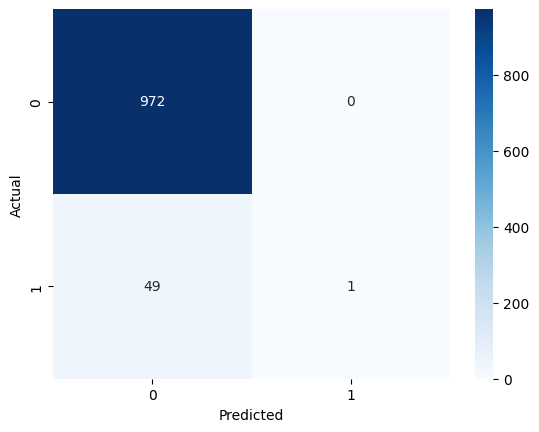

In [15]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

print("Accuracy :",accuracy_score(y_test,prediction))

print(classification_report(y_test,prediction))

sns.heatmap(confusion_matrix(y_test,prediction),
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train,y_train)

pred = rf.predict(X_test)

print("Accuracy :",accuracy_score(y_test,pred))

print(classification_report(y_test,pred))

Accuracy : 0.9481409001956947
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022



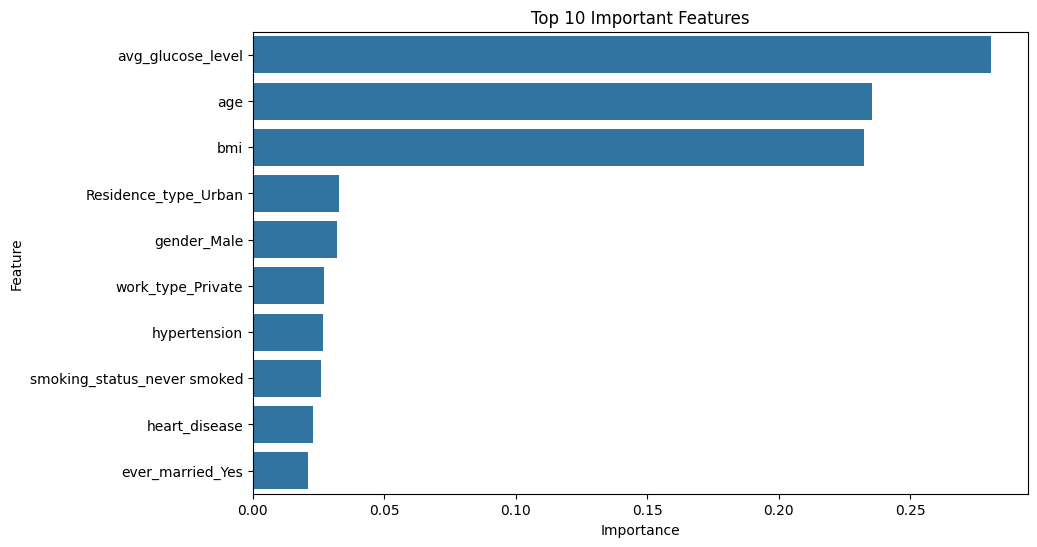

In [17]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":rf.feature_importances_
})

importance = importance.sort_values(by="Importance",ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(data=importance.head(10),
            x="Importance",
            y="Feature")

plt.title("Top 10 Important Features")

plt.show()